In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score,
                             roc_curve, accuracy_score, precision_score, recall_score, f1_score)
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import time
import warnings
import os
import csv
from sklearn.model_selection import cross_validate
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')

In [ ]:
# 2) Load data
df = pd.read_csv("data/Cleaned.csv")
target_col = "NoShow"

print("Shape:", df.shape)
print("Target distribution:\n", df[target_col].value_counts(normalize=True))

X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

# Identify categorical and numerical features
cat_thresh = 20
categorical_cols = [c for c in X.columns if X[c].dtype == 'object' or X[c].nunique() <= cat_thresh]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

print("Numerical:", numeric_cols)
print("Categorical:", categorical_cols)

Shape: (110526, 17)
Target distribution:
 NoShow
0    0.798066
1    0.201934
Name: proportion, dtype: float64
Numerical: ['Age', 'Neighbourhood', 'DaysToAppointment']
Categorical: ['Gender', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'ScheduledDay_DayOfWeek', 'AppointmentDay_DayOfWeek', 'ScheduledDay_Year', 'ScheduledDay_Month', 'AppointmentDay_Year', 'AppointmentDay_Month']


In [ ]:
# 3) Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

print("Train distribution:", np.bincount(y_train))
print("Test distribution:", np.bincount(y_test))

# 4) Oversampling (outside pipeline)
sampler_choice = "adasyn"
if sampler_choice == "smote":
    sampler = SMOTE(random_state=42)
elif sampler_choice == "adasyn":
    sampler = ADASYN(random_state=42)

X_train_res, y_train_res = sampler.fit_resample(X_train, y_train)
X_train_res = pd.DataFrame(X_train_res, columns=X_train.columns)
print("After resampling:", np.bincount(y_train_res))

# 5) Preprocessing
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)


Train distribution: [70565 17855]
Test distribution: [17642  4464]
After resampling: [70565 70090]


In [ ]:
# 6) Base models
rf = RandomForestClassifier(random_state=42, n_jobs=3)
xgb = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42, n_jobs=3)
mlp = MLPClassifier(max_iter=500, early_stopping=True, random_state=42)

# 7) Pipelines
pipe_rf = Pipeline(steps=[("preproc", preprocessor), ("clf", rf)])
pipe_xgb = Pipeline(steps=[("preproc", preprocessor), ("clf", xgb)])
pipe_mlp = Pipeline(steps=[("preproc", preprocessor), ("clf", mlp)])

# 8) Hyperparameter grids
rf_param_dist = {
    "clf__n_estimators": [100, 200, 400],
    "clf__max_depth": [2, 4, 6, 10, 20],
    "clf__min_samples_split": [2, 3, 5, 7, 10],
    "clf__class_weight": [None, "balanced"]
}
xgb_param_dist = {
    'clf__n_estimators': [100, 200, 300, 400, 800],
    'clf__max_depth': [2, 3, 4, 6, 8, 10],
    'clf__learning_rate': [0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.1, 0.15],
    'clf__subsample': [0.5, 0.7, 0.9, 1.0],
    'clf__colsample_bytree': [0.5, 0.7, 0.9, 1.0],
    'clf__gamma': [0, 0.1, 0.5, 1],
    'clf__reg_alpha': [0, 0.01, 0.1, 1],
    'clf__reg_lambda': [1, 2, 3, 4, 5]
}
mlp_param_dist = {
    "clf__hidden_layer_sizes": [(h, h, h) for h in (16, 32, 64, 128)],
    "clf__alpha": [1e-4, 1e-3, 1e-2],
    "clf__learning_rate_init": [1e-3, 1e-4]
}

# 9) Tuning function
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def tune_model(pipeline, param_dist, X_train, y_train, cv, n_iter=50, scoring="f1"):
    rs = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring=scoring,
        cv=cv,
        random_state=42,
        verbose=1,
        n_jobs=3,
        refit=True
    )
    rs.fit(X_train, y_train)
    print("Best score:", rs.best_score_)
    print("Best params:", rs.best_params_)
    return rs

# 10) Tune models
rs_rf = tune_model(pipe_rf, rf_param_dist, X_train_res, y_train_res, cv)
rs_xgb = tune_model(pipe_xgb, xgb_param_dist, X_train_res, y_train_res, cv)
rs_mlp = tune_model(pipe_mlp, mlp_param_dist, X_train_res, y_train_res, cv, n_iter=12)

# 11) Evaluation
def evaluate_model(model, X_test, y_test, name="model"):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan

    print(f"\n=== {name} ===")
    print("Acc:", acc, " Prec:", prec, " Rec:", rec, " F1:", f1, " AUC:", roc)
    print(classification_report(y_test, y_pred, digits=4))
    return {"name": name, "acc": acc, "prec": prec, "rec": rec, "f1": f1, "roc": roc, "y_prob": y_prob, "y_pred": y_pred}

res_rf = evaluate_model(rs_rf.best_estimator_, X_test, y_test, "RandomForest")
res_xgb = evaluate_model(rs_xgb.best_estimator_, X_test, y_test, "XGBoost")
res_mlp = evaluate_model(rs_mlp.best_estimator_, X_test, y_test, "MLP")



Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best score: 0.7838434461908963
Best params: {'clf__n_estimators': 400, 'clf__min_samples_split': 2, 'clf__max_depth': 20, 'clf__class_weight': 'balanced'}
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best score: 0.8060058250302315
Best params: {'clf__subsample': 0.5, 'clf__reg_lambda': 4, 'clf__reg_alpha': 0, 'clf__n_estimators': 800, 'clf__max_depth': 10, 'clf__learning_rate': 0.1, 'clf__gamma': 0.5, 'clf__colsample_bytree': 0.7}
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best score: 0.7360267109074535
Best params: {'clf__learning_rate_init': 0.001, 'clf__hidden_layer_sizes': (64, 64, 64), 'clf__alpha': 0.001}

=== RandomForest ===
Acc: 0.6852438252058265  Prec: 0.32441565756125035  Rec: 0.5161290322580645  F1: 0.39840913020923396  AUC: 0.702976200997213
              precision    recall  f1-score   support

           0     0.8560    0.7280    0.7869     17642
           1     0.3244    0

In [ ]:
# 12) Stacking ensemble
stack = StackingClassifier(
    estimators=[
        ("rf", rs_rf.best_estimator_.named_steps["clf"]),
        ("xgb", rs_xgb.best_estimator_.named_steps["clf"]),
        ("mlp", rs_mlp.best_estimator_.named_steps["clf"])
    ],
    final_estimator=XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42, n_jobs=3),
    cv=cv,
    n_jobs=3
)

final_pipeline = Pipeline(steps=[
    ("preproc", preprocessor),
    ("stack", stack)
])

final_pipeline.fit(X_train_res, y_train_res)
res_stack = evaluate_model(final_pipeline, X_test, y_test, "Stacking Ensemble")


=== Stacking Ensemble ===
Acc: 0.7266805392201212  Prec: 0.35196998123827394  Rec: 0.42025089605734767  F1: 0.38309168878905453  AUC: 0.7025664561475364
              precision    recall  f1-score   support

           0     0.8457    0.8042    0.8245     17642
           1     0.3520    0.4203    0.3831      4464

    accuracy                         0.7267     22106
   macro avg     0.5989    0.6122    0.6038     22106
weighted avg     0.7460    0.7267    0.7353     22106



In [ ]:
os.makedirs("outputs/ENSEMBLE", exist_ok=True)

# Collect and save results per fold and per model
def kfold_results_to_csv(model, X, y, cv, model_name,
                         detail_file="outputs/ENSEMBLE/kfold_results.csv",
                         summary_file="outputs/ENSEMBLE/kfold_summary.csv"):
    scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
    cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring, return_train_score=False)

    # ---- Detailed results per fold ----
    rows = []
    n_folds = len(cv_results["test_accuracy"])
    for i in range(n_folds):
      row = {
          "model": model_name,
          "fold": i + 1,
          "accuracy": cv_results["test_accuracy"][i],
          "precision": cv_results["test_precision"][i],
          "recall": cv_results["test_recall"][i],
          "f1": cv_results["test_f1"][i],
          "roc_auc": cv_results["test_roc_auc"][i],
      }
      rows.append(row)

    # Append to detailed CSV
    file_exists = os.path.isfile(detail_file)
    with open(detail_file, mode="a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=rows[0].keys())
        if not file_exists:
            writer.writeheader()
        writer.writerows(rows)

    # ---- Summary with mean and std ----
    summary_row = {
        "model": model_name,
        "accuracy_mean": np.mean(cv_results["test_accuracy"]),
        "accuracy_std": np.std(cv_results["test_accuracy"]),
        "precision_mean": np.mean(cv_results["test_precision"]),
        "precision_std": np.std(cv_results["test_precision"]),
        "recall_mean": np.mean(cv_results["test_recall"]),
        "recall_std": np.std(cv_results["test_recall"]),
        "f1_mean": np.mean(cv_results["test_f1"]),
        "f1_std": np.std(cv_results["test_f1"]),
        "roc_auc_mean": np.mean(cv_results["test_roc_auc"]),
        "roc_auc_std": np.std(cv_results["test_roc_auc"]),
    }

    file_exists = os.path.isfile(summary_file)
    with open(summary_file, mode="a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=summary_row.keys())
        if not file_exists:
            writer.writeheader()
        writer.writerow(summary_row)

    print(f"Saved detailed and summary k-fold results for {model_name}")

# Example usage with tuned models:
kfold_results_to_csv(rs_rf.best_estimator_, X_train_res, y_train_res, cv, "RandomForest")
kfold_results_to_csv(rs_xgb.best_estimator_, X_train_res, y_train_res, cv, "XGBoost")
kfold_results_to_csv(rs_mlp.best_estimator_, X_train_res, y_train_res, cv, "MLP")
kfold_results_to_csv(final_pipeline, X_train_res, y_train_res, cv, "Stacking Ensemble")


Saved detailed and summary k-fold results for RandomForest
Saved detailed and summary k-fold results for XGBoost
Saved detailed and summary k-fold results for MLP
Saved detailed and summary k-fold results for Stacking Ensemble


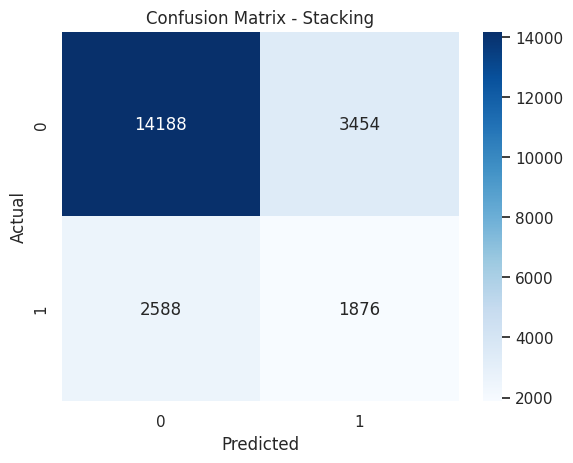

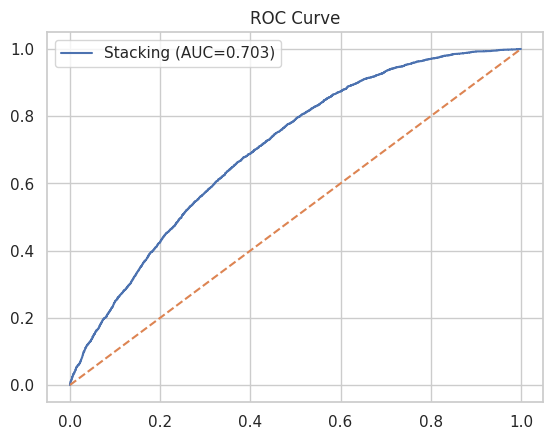

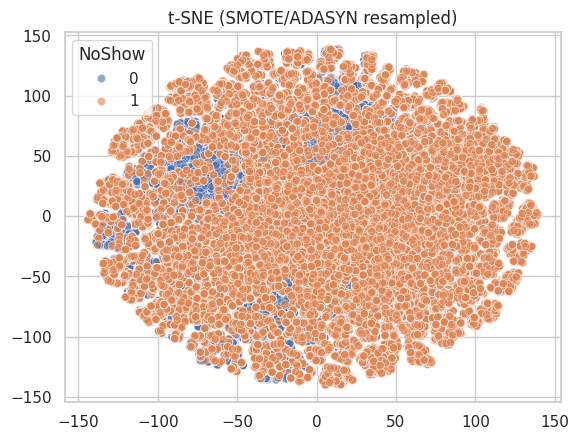

In [ ]:
# 13) Visualizations
def plot_confusion(y_test, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.show()

plot_confusion(y_test, res_stack["y_pred"], "Confusion Matrix - Stacking")

if res_stack["y_prob"] is not None:
    fpr, tpr, _ = roc_curve(y_test, res_stack["y_prob"])
    plt.plot(fpr, tpr, label=f"Stacking (AUC={res_stack['roc']:.3f})")
    plt.plot([0,1],[0,1],"--")
    plt.legend(); plt.title("ROC Curve"); plt.show()

# 14) t-SNE visualization
Xp_res = preprocessor.fit_transform(X_train_res)
Xp_res_pca = PCA(n_components=min(50, Xp_res.shape[1]), random_state=42).fit_transform(Xp_res)
Xp_res_tsne = TSNE(n_components=2, random_state=42, init="pca").fit_transform(Xp_res_pca)
sns.scatterplot(x=Xp_res_tsne[:,0], y=Xp_res_tsne[:,1], hue=y_train_res, alpha=0.6, palette="deep")
plt.title("t-SNE (SMOTE/ADASYN resampled)")
plt.show()

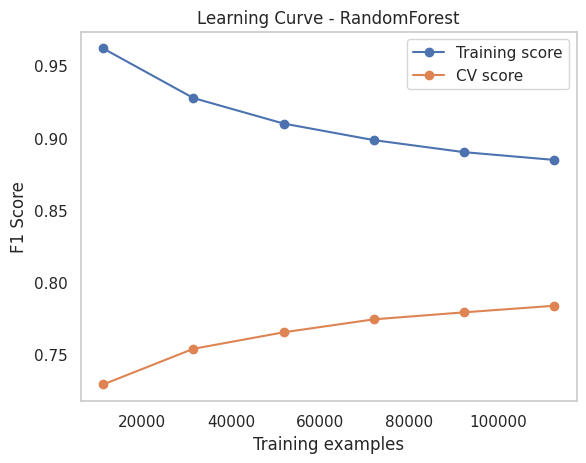

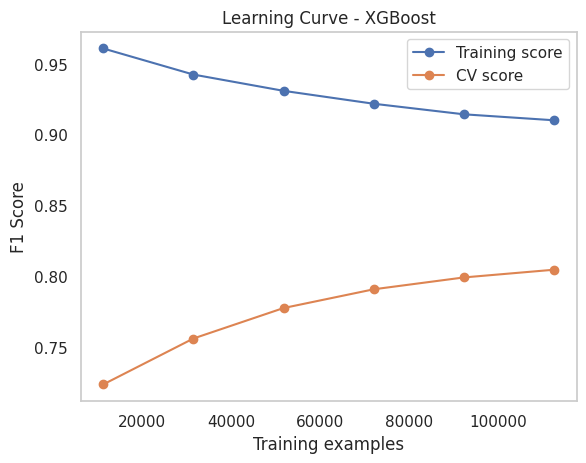

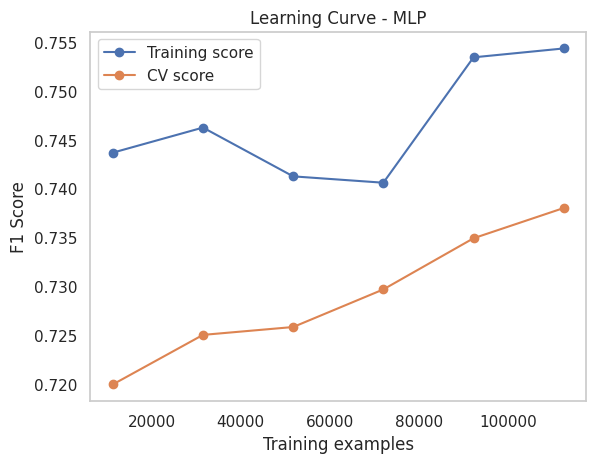

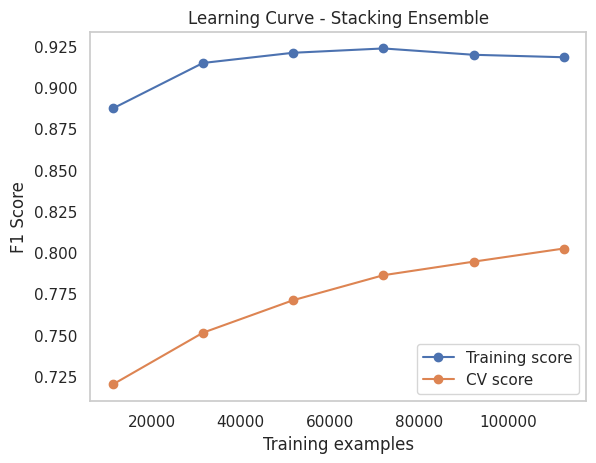

In [ ]:
# 15) Learning Curves
def plot_learning_curve(model, X, y, title="Learning Curve"):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y,
        cv=cv,
        scoring="f1",
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 6),
        shuffle=True,
        random_state=42
    )
    train_mean = train_scores.mean(axis=1)
    test_mean = test_scores.mean(axis=1)

    plt.figure()
    plt.plot(train_sizes, train_mean, "o-", label="Training score")
    plt.plot(train_sizes, test_mean, "o-", label="CV score")
    plt.xlabel("Training examples")
    plt.ylabel("F1 Score")
    plt.title(title)
    plt.legend(loc="best")
    plt.grid()
    plt.show()

# Plot learning curves for each tuned model
plot_learning_curve(rs_rf.best_estimator_, X_train_res, y_train_res, "Learning Curve - RandomForest")
plot_learning_curve(rs_xgb.best_estimator_, X_train_res, y_train_res, "Learning Curve - XGBoost")
plot_learning_curve(rs_mlp.best_estimator_, X_train_res, y_train_res, "Learning Curve - MLP")
plot_learning_curve(final_pipeline, X_train_res, y_train_res, "Learning Curve - Stacking Ensemble")
